# Searching for Layer Dependencies


## Overview

This notebook will look for any items (web maps, apps) which are dependent upon a layer. This is a great tool to use prior to removing or replacing a layer, to ensure that you've addressed anywhere this layer shows up.

In brief, this notebook will:

1. Take a given service's ItemID
2. Find the associated service URL
3. Iterate over all maps in your org, looking for your service in:

   - Operational layers  
   - Basemap layers  
   - Anywhere else (search widget, etc.)

Matches will be printed out for user review.

## Setup

In [19]:
import pandas as pd
from IPython.display import display

import arcgis
from arcgis.gis import GIS

#### Connect to ArcGIS Online

<User username:aolson_c3>
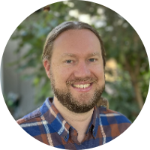

In [20]:
gis = GIS(profile='aolson_prfl2')
gis.users.me

### Input Item ID or URL

Run this cell to specify the service you're looking for by its `ItemID`.

Leave the first input blank to search by the service URL instead. Useful if you're looking for a specific sub-layer of the service.

Example item id for Wards: 29b731dad9894c5eb1223089aa5a35a8

Or, the url for Wards: https://services.arcgis.com/iyZLRarIZZa0GHya/arcgis/rest/services/New_Wards_2023/FeatureServer/17

In [26]:
find_id = input('ItemID: ')

find_url = gis.content.get(find_id).url if find_id else input('Service URL: ')
print(find_url)

ItemID:  63b99293c37a431f845fa15555ce303e


https://arcgis.c3gov.com/arcgis/rest/services/Parcel_Finder_Web_Map/CC_Parcels/MapServer


## The Search

### Web Maps

First, we will be getting a list of **all** the web maps in my org.

For each web map, it's as simple as using `get_data()` to return the JSON definition of the map as a string. We can then use `find` together with our service URL to see if it shows up.

Our `map_list` is created using **list comprehension** together with a **ternary operator**, which are very handy features for keeping your Python concise.

#### Searching outside your org

Add the parameter `outside_org=True` to the **search** to look for maps from *any* AGOL organization that are shared publicly. Obviously, that's going to be a LOT of information to look through, so only do that if you're certain you want to, then go get some coffee or something while it executes.

In [27]:
webmaps = gis.content.search('', item_type='Web Map', max_items=-1, outside_org=False)

Output a count of all the 'Web Map' items found in the content search.

In [28]:
len(webmaps)

400

Output the first list item found in the web map list.

<Item title:"Second Creek Community Park" type:Web Map owner:tferguson_c3>
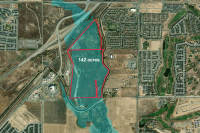

In [29]:
webmaps[0]

### Web Apps

Now we'll be getting a list of **all** the web apps in my org. There are different `item_type`s for each, so we need to perform multiple queries and merge them together. Again, list comprehension makes this a nice short line, rather than nested for-loops.

In [30]:
apptypes = ['Application', 'Dashboard', 'Story Map', 'Web Experience']

webapps = [item for sublist in [gis.content.search('', item_type=t, max_items=-1, outside_org=False) for t in apptypes] for item in sublist]

Output a count of all the 'Application', 'Dashboard', 'Story Map', 'Web Experience' items found in the content search.

In [31]:
len(webapps)

344

## Match Item ID and/or URL

Now that we have our apps, searching through them is a little different. A web map may reference your layer directly, using its URL **or** its ItemID. It may also simply reference the web map which contains your layer.

### Web Map Item ID or URL Matching

Here you need to define what criteria you are searching for in your web maps. If it is a Item ID, URL, or both, you need to change the script bellow in the criteria variable. All 'Web Maps' that are found to contain the Item ID or the URL will be stored in a new list to be writen into a pandas dataframe later on. 

In [32]:
# For searching web maps by Item ID
map_id_list = [m for m in webmaps if str(m.get_data()).find(find_id) > -1]

In [33]:
# For seaching web maps by URL
map_url_list = [m for m in webmaps if str(m.get_data()).find(find_url) > -1]

Output a count of maps that were found using the Item ID and/or the URL

In [34]:
len(map_id_list)

8

In [35]:
len(map_url_list)

12

### Web App Item ID Matching

To search each of these, we create a list of `criteria`, then we use `any` to see if one or more of the criteria evaluate to `True`. When that is the case, we append that web app to a list of apps.

Run this code block to search apps for an Item ID

In [36]:
app_list = []

# if searching by item id 
for w in webapps:
    try:
        wdata = str(w.get_data())
        criteria = [
            wdata.find(find_id) > -1,
            any([wdata.find(m.id) > -1 for m in map_id_list])
        ]
        
        if any(criteria):
            app_list.append(w)
        
    # Some apps don't have data, so we'll just skip them if they throw a TypeError
    except:
        continue

Output a count of apps that were found using the Item ID

In [37]:
len(app_list)

4

Run this code block to search apps for a URL

In [38]:
app_list = []

# if searching by url
for w in webapps:
    try:
        wdata = str(w.get_data())
        criteria = [
            wdata.find(find_url) > -1,
            any([wdata.find(m.id) > -1 for m in map_url_list])
        ]
        
        if any(criteria):
            app_list.append(w)
        
    # Some apps don't have data, so we'll just skip them if they throw a TypeError
    except:
        continue

Output a count of apps that were found using the Item ID and/or the URL

In [ ]:
len(app_list)

### Reviewing the Output

The two lists of dependent Web Maps and Web Apps can be queried for additional information about usage, creation date etc.

Use the `usage` method to query usage information about an individual list item. You can define the desired time frame or the date range using `data_range`

In [ ]:
app_list[0].usage(date_range="7D")

In [ ]:
app_list[0].created

In [ ]:
app_list[0].owner

In [ ]:
app_list[0].type

### Create Dataframe

Now we've got our lists of maps and apps. But to get them in a user-friendly format, we'll use `pandas` to cobble together a dataframe.

In [ ]:
dependencies = pd.concat(
    [
        pd.DataFrame([{'title':a.title, 'id':a.id, 'type':a.type, 'url':f'{gis.url}/home/item.html?id={a.id}', 'data':a.get_data()} for a in app_list]),
        pd.DataFrame([{'title':m.title, 'id':m.id, 'type':m.type, 'url':f'{gis.url}/home/item.html?id={m.id}', 'data':m.get_data()} for m in map_list])
    ]
)

dependencies.reset_index(inplace=True, drop=True)

dependencies.head()

### Looking at A Specific Dataframe Item

Use `columns.values` to find a full list of fields that can be queried in the dataframe.

In [ ]:
dependencies.columns.values

Show data info for the first record in the dataframe using `loc`

In [ ]:
dependencies.loc[0,'data']

In [ ]:
dependencies.loc[0,'url']

## What now?

Now you've got your output, but what do you do with it? Well, you could use dependencies.to_csv() to save the dataframe to a file. If you're just tracking down references to your service to replace or remove them, you can use the url column to go straight to the item's page in your portal and make the necessary adjustments.

In [ ]:
myCSV = dependencies.to_csv()

In [ ]:
myCSV